# Cropping and aligning raster data

Crop a Sentinel-2 raster to the Rhodes assets (from notebook 04) first with a bounding box and then with the polygon itself, clip the red band to the island boundary, and align a DEM to the cropped raster with `reproject_match`. Inputs are read from `../data/` and `../outputs/`; the matched DEM is written to `../outputs/`.

## 1. Load the data

In [1]:
import rioxarray

path_visual = "../data/sentinel2/visual.tif"
visual = rioxarray.open_rasterio(path_visual, overview_level=1)
visual

<xarray.DataArray (band: 3, y: 2745, x: 2745)> Size: 23MB
[22605075 values with dtype=uint8]
Coordinates:
  * band         (band) int64 24B 1 2 3
  * y            (y) float64 22kB 4.1e+06 4.1e+06 4.1e+06 ... 3.99e+06 3.99e+06
  * x            (x) float64 22kB 5e+05 5e+05 5.001e+05 ... 6.097e+05 6.098e+05
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0

In [2]:
import geopandas as gpd

assets = gpd.read_file("../outputs/assets.gpkg")

## 2. Crop the raster with a bounding box

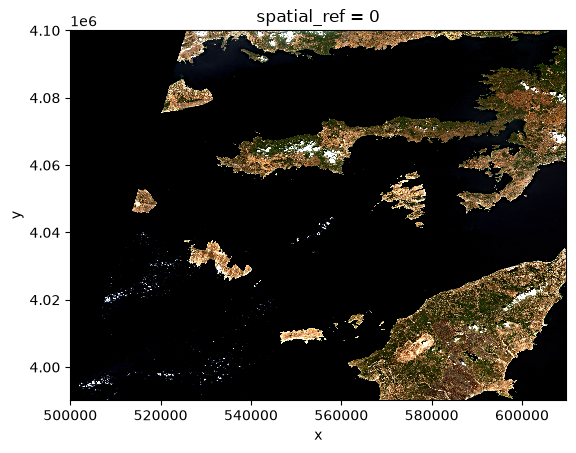

In [3]:
visual.plot.imshow()

In [4]:
assets.total_bounds

array([27.71628289, 35.89024659, 28.24128748, 36.4569273 ])

In [5]:
# Reproject the vector data to match the raster CRS
assets = assets.to_crs(visual.rio.crs)

# Check the new bounding box
assets.total_bounds

array([ 564461.41472579, 3972051.52011189,  611329.30664851,
       4035322.51020083])

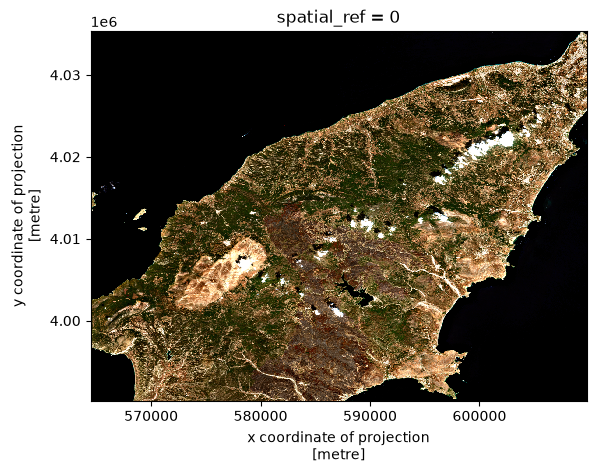

In [6]:
# Crop the raster with the bounding box
visual_clipbox = visual.rio.clip_box(*assets.total_bounds)

# Visualize the cropped image
visual_clipbox.plot.imshow()

## 3. Crop the raster with a polygon

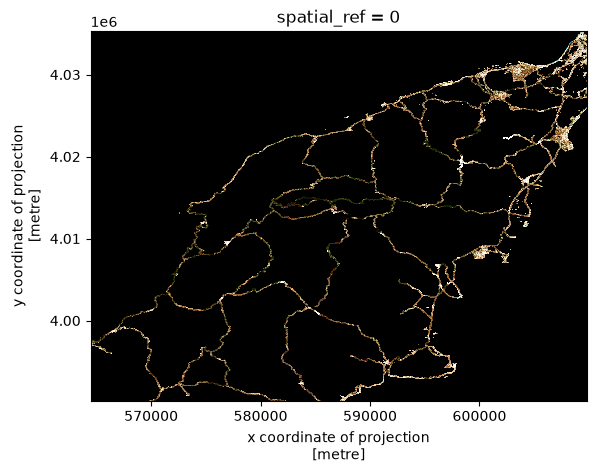

In [7]:
# Crop the raster with the polygon
visual_clip = visual_clipbox.rio.clip(assets["geometry"])

# Visualize the cropped image
visual_clip.plot.imshow()

## 4. Exercise: clip the red band to Rhodes

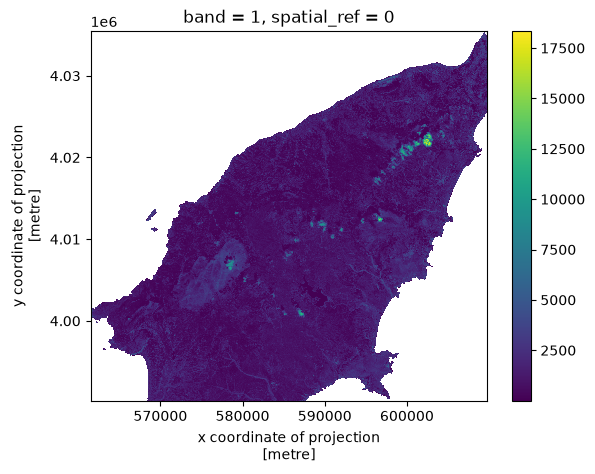

In [8]:
# Step 1 - Load the vector data and select Rhodes
import geopandas as gpd
gdf_greece = gpd.read_file("../data/gadm/ADM_ADM_3.gpkg")
gdf_rhodes = gdf_greece[gdf_greece["NAME_3"] == "Rhodos"]

# Step 2 - Load the raster red band
import rioxarray
path_red = "../data/sentinel2/red.tif"
red = rioxarray.open_rasterio(path_red, overview_level=1)

# Step 3 - Reproject the vector to the raster CRS (clip fails otherwise)
gdf_rhodes = gdf_rhodes.to_crs(red.rio.crs)

# Step 4 - Clip the raster to the polygon
red_clip = red.rio.clip(gdf_rhodes["geometry"])

# Step 5 - Assign NaN to the no-data value
red_clip_nan = red_clip.where(red_clip != red_clip.rio.nodata)

# Step 6 - Visualize the result
red_clip_nan.plot()

## 5. Match two rasters with reproject_match

In [9]:
dem = rioxarray.open_rasterio("../data/dem/rhodes_dem.tif")

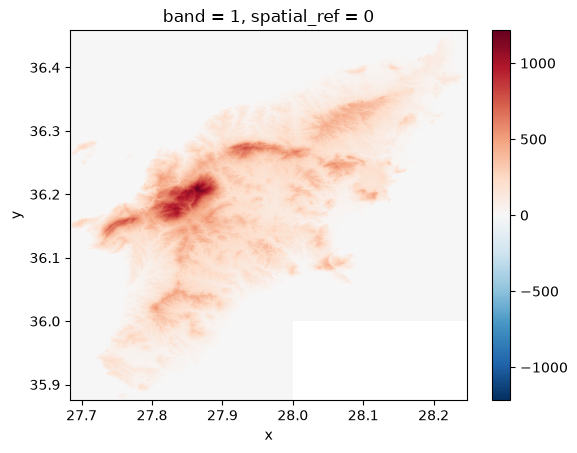

In [10]:
dem.plot()

In [11]:
print(dem.rio.crs)
print(visual_clip.rio.crs)

EPSG:4326
EPSG:32635


In [12]:
dem_matched = dem.rio.reproject_match(visual_clip)

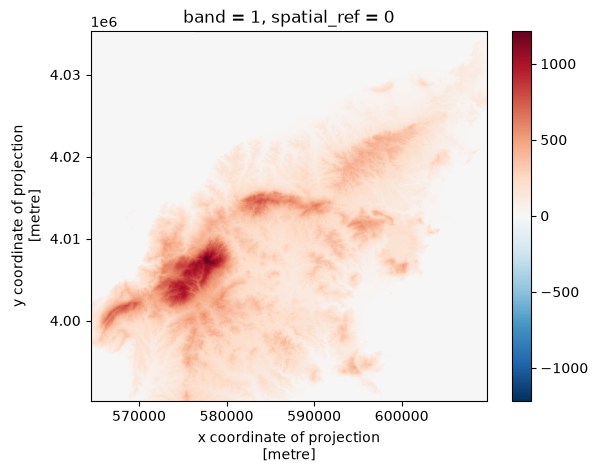

In [13]:
dem_matched.plot()

In [14]:
dem_matched.rio.to_raster("../outputs/dem_rhodes_match.tif", driver="COG")